Simple CNN Implementation using keras.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
# Load a sample dataset (MNIST for simplicity)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
# Normalize and reshape data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, axis=-1) # Add channel dimension
x_test = np.expand_dims(x_test, axis=-1)
# Define a simple CNN model
model = keras.Sequential([
layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
layers.MaxPooling2D((2, 2)),
layers.Conv2D(64, (3, 3), activation="relu"),
layers.MaxPooling2D((2, 2)),
layers.Flatten(),
layers.Dense(128, activation="relu"),
layers.Dense(10, activation="softmax") # 10 classes for MNIST digits
])
# Compile the model
model.compile(optimizer="adam",

loss="sparse_categorical_crossentropy",
metrics=["accuracy"])

# Train the model
model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test))
# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")
# Make predictions
predictions = model.predict(x_test[:5])
predicted_labels = np.argmax(predictions, axis=1)
print("Predicted labels:", predicted_labels)
print("Actual labels: ", y_test[:5])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 66s 34ms/step - accuracy: 0.9590 - loss: 0.1306 - val_accuracy: 0.9836 - val_loss: 0.0498
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 85s 36ms/step - accuracy: 0.9869 - loss: 0.0427 - val_accuracy: 0.9859 - val_loss: 0.0429
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 74s 32ms/step - accuracy: 0.9906 - loss: 0.0305 - val_accuracy: 0.9883 - val_loss: 0.0369
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 32ms/step - accuracy: 0.9932 - loss: 0.0220 - val_accuracy: 0.9882 - val_loss: 0.0388
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9946 - loss: 0.0161 - val_accuracy: 0.9919 - val_loss: 0.0264
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9919 - loss: 0.0264
Test accuracy: 0.9919
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Predicted labels: [7 2 1 0 4]
Actual labels:  [7 2 1 0 4]


Task 1: Loading data

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import zipfile

zip_path = "/content/drive/MyDrive/AI_Datasets/FruitinAmazon.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

Dataset extracted!


Checking for corrupted images

In [8]:
from PIL import Image
import os

train_dir =  "/content/dataset/FruitinAmazon/train"

corrupted_images = []

for root, dirs, files in os.walk(train_dir):
    for file in files:
        file_path = os.path.join(root, file)
        try:
            img = Image.open(file_path)
            img.verify()
        except (IOError, SyntaxError):
            corrupted_images.append(file_path)
            os.remove(file_path)
            print(f"Removed corrupted image: {file_path}")

if len(corrupted_images) == 0:
    print("No corrupted images found.")

No corrupted images found.


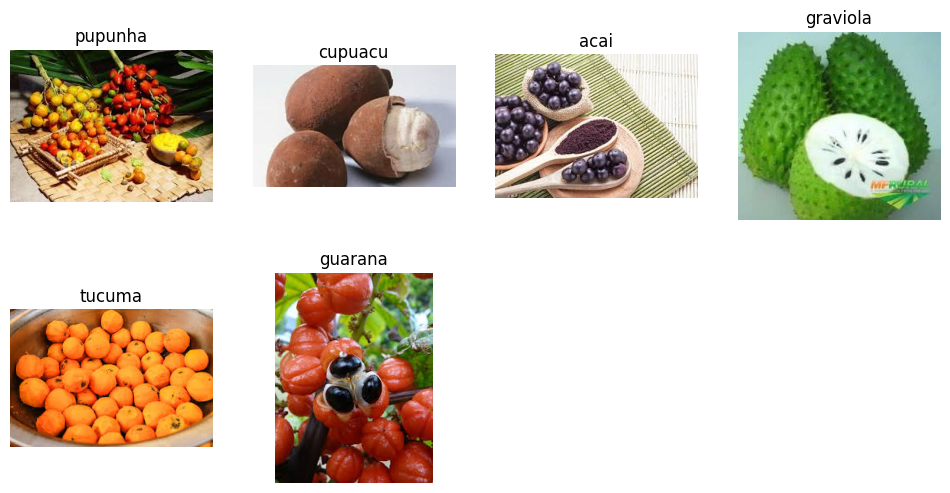

In [9]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

train_dir = "/content/dataset/FruitinAmazon/train"

classes = os.listdir(train_dir)

plt.figure(figsize=(12,6))

for i, cls in enumerate(classes):
    class_path = os.path.join(train_dir, cls)

    # Skip if not a directory
    if not os.path.isdir(class_path):
        continue

    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(2, (len(classes)//2)+1, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

Task 2: Loading and processing data

In [10]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

train_dir = "/content/dataset/FruitinAmazon/train"

# Normalization layer
rescale = tf.keras.layers.Rescaling(1./255)

# Training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)


class_names = train_ds.class_names
num_classes = len(class_names)

# Apply normalization
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

val_ds = val_ds.map(lambda x, y: (rescale(x), y))

print("Classes:", class_names)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


Task 3 : Building the CNN model

In [11]:
from tensorflow.keras import layers, models

model = models.Sequential([

    # Conv Layer 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    # Conv Layer 2
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten
    layers.Flatten(),

    # Dense Layers
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

Task 4: Compiling Model

In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Task 5: Training model

In [13]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.1204 - loss: 2.3377
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 597ms/step - accuracy: 0.1111 - loss: 2.5644 - val_accuracy: 0.0000e+00 - val_loss: 1.7894
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.1991 - loss: 1.8547
Epoch 2: val_accuracy did not improve from 0.00000
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 466ms/step - accuracy: 0.2222 - loss: 1.8412 - val_accuracy: 0.0000e+00 - val_loss: 2.0662
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.2182 - loss: 1.7461
Epoch 3: val_accuracy did not improve from 0.00000
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 473ms/step - accuracy: 0.2639 - loss: 1.7243 - val_accuracy: 0.0000e+00 - val_loss: 1.7965
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.3796 - loss: 1.6555
Epoch 4: val_accuracy improved from 0.00000 to 0.27778, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 832ms/step - accuracy: 0.3889 - loss: 1.6457 - val_accuracy: 0.2778 - val_loss: 1.7206
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 608ms/step - accuracy: 0.3594 - loss: 1.5752
Epoch 5: val_accuracy improved from 0.27778 to 0.72222, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 851ms/step - accuracy: 0.3750 - loss: 1.5586 - val_accuracy: 0.7222 - val_loss: 1.5159
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.3600 - loss: 1.4767
Epoch 6: val_accuracy did not improve from 0.72222
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 461ms/step - accuracy: 0.3611 - loss: 1.4521 - val_accuracy: 0.6111 - val_loss: 1.4676
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.3941 - loss: 1.3385
Epoch 7: val_accuracy did not improve from 0.72222
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 432ms/step - accuracy: 0.4167 - loss: 1.3594 - val_accuracy: 0.5556 - val_loss: 1.2770
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.5191 - loss: 1.2411
Epoch 8: val_accuracy did not improve from 0.72222
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 436ms/step - accuracy: 0.5417 - loss: 1.2135 - val_accuracy: 0.6111 - val_loss: 1.2676
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.5856 - loss: 1.073


Epoch 9: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 475ms/step - accuracy: 0.5694 - loss: 1.0854 - val_accuracy: 0.7778 - val_loss: 0.9199
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.7008 - loss: 0.9308
Epoch 10: val_accuracy did not improve from 0.77778
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 424ms/step - accuracy: 0.6806 - loss: 0.9526 - val_accuracy: 0.5000 - val_loss: 1.0838
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.7350 - loss: 0.8137
Epoch 11: val_accuracy did not improve from 0.77778
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 452ms/step - accuracy: 0.7361 - loss: 0.7706 - val_accuracy: 0.2222 - val_loss: 1.5607
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.7807 - loss: 0.6971
Epoch 12: val_accuracy did not improve from 0.77778
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 485ms/step - accuracy: 0.7639 - loss: 0.6918 - val_accuracy: 0.7778 - val_loss: 0.9180
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 606ms/step - accuracy: 0.8652 - loss


Epoch 13: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 835ms/step - accuracy: 0.8611 - loss: 0.5458 - val_accuracy: 0.8333 - val_loss: 0.7664
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 565ms/step - accuracy: 0.8796 - loss: 0.4390
Epoch 14: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 749ms/step - accuracy: 0.8889 - loss: 0.4297 - val_accuracy: 0.7222 - val_loss: 0.7499
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.8947 - loss: 0.3821
Epoch 15: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 426ms/step - accuracy: 0.9028 - loss: 0.3646 - val_accuracy: 0.7778 - val_loss: 0.8033
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.9902 - loss: 0.2380
Epoch 16: val_accuracy improved from 0.83333 to 0.88889, saving model to best_model.h5



Epoch 16: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 479ms/step - accuracy: 0.9861 - loss: 0.2177 - val_accuracy: 0.8889 - val_loss: 0.3799
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.9601 - loss: 0.2470
Epoch 17: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 435ms/step - accuracy: 0.9583 - loss: 0.2525 - val_accuracy: 0.7222 - val_loss: 0.6831
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.9705 - loss: 0.1384
Epoch 18: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 452ms/step - accuracy: 0.9583 - loss: 0.1584 - val_accuracy: 0.7222 - val_loss: 1.0081
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.9803 - loss: 0.1028
Epoch 19: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 441ms/step - accuracy: 0.9722 - loss: 0.1002 - val_accuracy: 0.8333 - val_loss: 0.5432
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.9601 - los

Task 6: Evaluating the model

In [ ]:
test_loss, test_acc = model.evaluate(val_ds)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

Task 7: Saving and loading model

In [ ]:
# Save model
model.save("final_model.h5")

# Load model
from tensorflow.keras.models import load_model

loaded_model = load_model("final_model.h5")

# Evaluate again
loss, acc = loaded_model.evaluate(val_ds)
print("Loaded Model Accuracy:", acc)

Task 8: Predicting and classification report

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in train_ds:
    predictions = loaded_model.predict(images)
    preds = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print("Unique y_true:", set(y_true))

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

The above result shows an over all accuracy of 89% including all the six fruit classes.